In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd


# --- Cargar CSV ---
df_train = pd.read_csv('/content/drive/My Drive/Datos_train_sAct.csv')
df_test  = pd.read_csv('/content/drive/My Drive/Datos_test_sAct.csv')
# --- Eliminar columna "Motivo de baja" ---
df_train = df_train.drop('Fecha de evaluación_num', axis=1)
df_test = df_test.drop('Fecha de evaluación_num', axis=1)

df_train = df_train.drop('Inscripción / Reinscripción', axis=1)
df_test = df_test.drop('Inscripción / Reinscripción', axis=1)


df_train = df_train.drop('Matrícula', axis=1)
df_test = df_test.drop('Matrícula', axis=1)
print(df_train.dtypes)

print("*******************+")
print(df_test.dtypes)


Número de hermanos en la familia            float64
Ingresos por apoyo gubernamental            float64
Total de ingresos mensuales                 float64
Total de egresos                            float64
Ingreso Per Cápita                          float64
Porcentaje de Beca                          float64
Fecha de nacimiento en dias                 float64
Edad en años                                float64
Edad_en_fecha_de_registro_dias              float64
Sexo                                         object
Programa                                     object
Grupo                                        object
Transporte del INA                           object
Clínica de Adscripción en el IMSS            object
Inst. en la que reciben servicio médico      object
Ciudad                                       object
Estado                                       object
Hospital donde nació                         object
Medio x el cual se enteró de Institución     object
Ocupación de

In [3]:
# Importaciones necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

# --- Separar variables y etiquetas ---
X_train = df_train.drop(['Baja General'], axis=1)
y_train = df_train['Baja General'].astype(int)

X_test = df_test.drop(['Baja General'], axis=1)
y_test = df_test['Baja General'].astype(int)

# --- Convertir booleanos a int ---
X_train = X_train.applymap(lambda v: int(v) if isinstance(v, bool) else v)
X_test  = X_test.applymap(lambda v: int(v) if isinstance(v, bool) else v)

# --- Identificar columnas categóricas ---
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# --- OneHotEncoder con handle_unknown='ignore' ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar con train y transformar ambos conjuntos
X_train_ohe = ohe.fit_transform(X_train[categorical_cols])
X_test_ohe  = ohe.transform(X_test[categorical_cols])

# Convertir a DataFrame con nombres de columnas
ohe_cols = ohe.get_feature_names_out(categorical_cols)
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_test_ohe  = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

# Reemplazar columnas categóricas originales por las codificadas
X_train = X_train.drop(categorical_cols, axis=1)
X_test  = X_test.drop(categorical_cols, axis=1)

X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test  = pd.concat([X_test, X_test_ohe], axis=1)

print(f"Columnas finales: {X_train.columns.tolist()}")

# --- Escalado de características ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Calcular class weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Pesos de clase:", class_weights)


Columnas finales: ['Número de hermanos en la familia', 'Ingresos por apoyo gubernamental', 'Total de ingresos mensuales', 'Total de egresos', 'Ingreso Per Cápita', 'Porcentaje de Beca', 'Fecha de nacimiento en dias', 'Edad en años', 'Edad_en_fecha_de_registro_dias', 'Internet_si', 'Teléfono_si', 'Luz_si', 'Sexo_Femenino', 'Sexo_Masculino', 'Programa_Asesoría Integral', 'Programa_Asesoría para el hogar', 'Programa_Atención Temprana', 'Programa_BRISA', 'Programa_Educación', 'Programa_Educación e Inclusión Educativa', 'Programa_Extensión Domiciliaria', 'Programa_Habilidades Adaptativas', 'Programa_Habilidades Funcionales', 'Programa_Habilidades para el Aprendizaje', 'Programa_Inclusión Educativa', 'Programa_Intervención Temprana', 'Programa_Maternal', 'Programa_Neurodesarrollo', 'Programa_PROVYT', 'Programa_Pre-Escolar', 'Programa_Primaria', 'Programa_Psicomotricidad', 'Programa_Servicios de Extensión', 'Grupo_A', 'Grupo_B', 'Grupo_C', 'Grupo_D', 'Grupo_Educación elemental A', 'Grupo_Educ

/tmp/ipython-input-1334269997.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train = X_train.applymap(lambda v: int(v) if isinstance(v, bool) else v)
/tmp/ipython-input-1334269997.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test  = X_test.applymap(lambda v: int(v) if isinstance(v, bool) else v)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers


ENTRENANDO RED NEURONAL MEJORADA Y MÁS PROFUNDA


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - AUC: 0.5348 - accuracy: 0.4901 - loss: 2.2144 - precision: 0.6835 - recall: 0.4085 - val_AUC: 0.5441 - val_accuracy: 0.6340 - val_loss: 1.9196 - val_precision: 0.6907 - val_recall: 0.8375 - learning_rate: 5.0000e-04
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.5769 - accuracy: 0.5417 - loss: 2.0477 - precision: 0.7382 - recall: 0.4910 - val_AUC: 0.6010 - val_accuracy: 0.6043 - val_loss: 1.8191 - val_precision: 0.7107 - val_recall: 0.7063 - learning_rate: 5.0000e-04
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.6770 - accuracy: 0.6240 - loss: 1.8315 - precision: 0.8154 - recall: 0.5708 - val_AUC: 0.6379 - val_accuracy: 0.6426 - val_loss: 1.7532 - val_precision: 0.7676 - val_recall: 0.6812 - learning_rate: 5.0000e-04
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.6706 - accuracy: 0.6120 - loss: 1.7728 - precision: 0.7668 - recall: 0.5763 - val_AUC: 0.6727 - val_accuracy: 0.6255 - val_loss: 1.

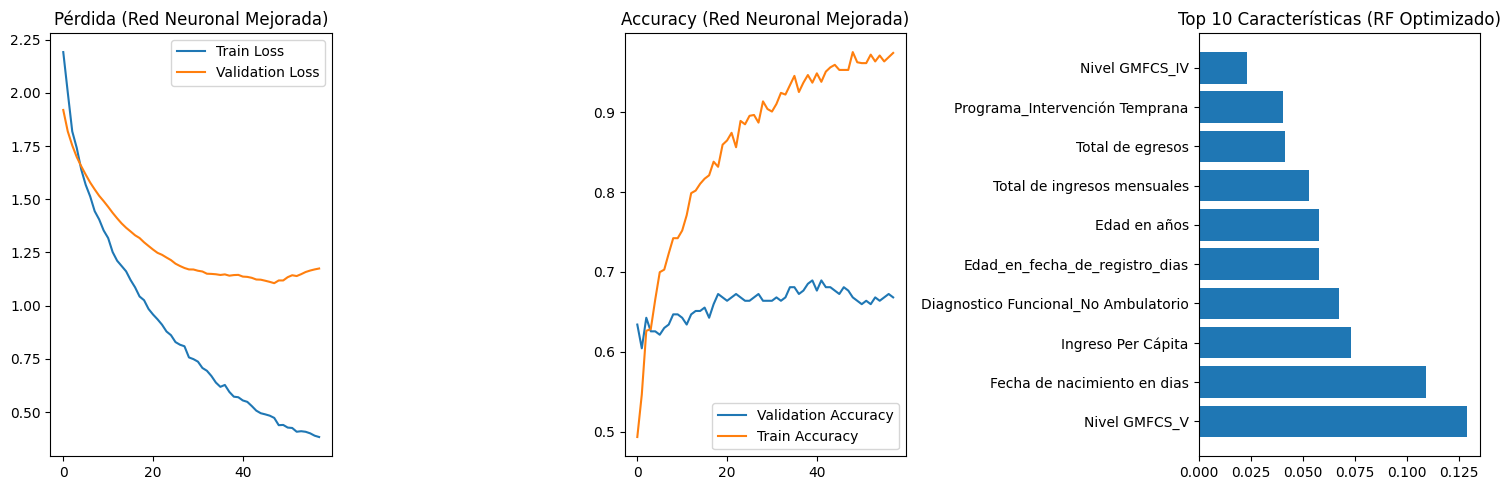


COMPARATIVA FINAL DE MODELOS
RED NEURONAL MEJORADA - Accuracy: 0.0000, AUC: 0.7556
RANDOM FOREST ORIGINAL - Accuracy: 0.7064, AUC: 0.8166
RANDOM FOREST OPTIMIZADO - Accuracy: 0.7191, AUC: 0.8217

Mejores parámetros para RF: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10, 'bootstrap': True}

------------------------------------------------------------

📊 REPORTE DETALLADO RED NEURONAL MEJORADA:
              precision    recall  f1-score   support

           0       0.50      0.73      0.59        75
           1       0.84      0.65      0.73       160

    accuracy                           0.68       235
   macro avg       0.67      0.69      0.66       235
weighted avg       0.73      0.68      0.69       235


📊 REPORTE DETALLADO RANDOM FOREST (OPTIMIZADO):
              precision    recall  f1-score   support

           0       0.55      0.67      0.60        75
           1       0.83      0.74      0.78       160

  

In [6]:
# --- RED NEURONAL MEJORADA ---
print("\n" + "="*50 + "\nENTRENANDO RED NEURONAL MEJORADA Y MÁS PROFUNDA\n" + "="*50)
model_nn = Sequential([
    # CAPA 1: Menos neuronas para reducir la complejidad del modelo
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)), # Se mantiene una regularización L2 fuerte
    BatchNormalization(),
    Dropout(0.5), # Un Dropout alto es nuestra principal defensa contra el overfitting

    # CAPA 2: Una segunda capa más pequeña para capturar patrones sin memorizar
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.005)),
    BatchNormalization(),
    # No se añade Dropout aquí para no restringir en exceso al modelo ya simplificado

    # CAPA DE SALIDA
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=Adam(learning_rate=0.0005), # Un learning rate bajo ayuda a una convergencia más estable
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall', 'AUC']
)

# CALLBACKS MÁS REACTIVOS: Detienen el entrenamiento antes si no hay mejora
early_stop_strict = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_strict = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)

history_improved = model_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150, batch_size=64, class_weight=class_weights,
    callbacks=[early_stop_strict, reduce_lr_strict], verbose=1
)

# --- EVALUACIÓN ROBUSTA ---
results_nn_improved_list = model_nn.evaluate(X_test_scaled, y_test, verbose=0)
results_nn_improved_dict = dict(zip(model_nn.metrics_names, results_nn_improved_list))
y_pred_proba_nn_improved = model_nn.predict(X_test_scaled)
y_pred_nn_improved = (y_pred_proba_nn_improved > 0.5).astype(int).flatten()


# --- RANDOM FOREST (ORIGINAL) ---
# Se mantiene igual para fines de comparación
print("\n" + "="*50 + "\nENTRENANDO RANDOM FOREST ORIGINAL\n" + "="*50)
model_rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]


# --- RANDOM FOREST (OPTIMIZADO CON BÚSQUEDA AMPLIADA) ---
print("\n" + "="*50 + "\nOPTIMIZANDO RANDOM FOREST (BÚSQUEDA AMPLIADA)\n" + "="*50)
param_dist = {
    'n_estimators': [200, 300, 400, 500],             # <-- Más opciones de estimadores
    'max_features': ['sqrt', 'log2', 0.5],            # <-- AÑADIDO: Se optimiza este hiperparámetro clave
    'max_depth': [10, 15, 20, 25, None],              # <-- Rango de profundidad ampliado
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'bootstrap': [True, False]                        # <-- AÑADIDO: Se prueba con y sin bootstrap
}

rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,  # <-- AUMENTADO: Más iteraciones para explorar el espacio de búsqueda más grande
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)
rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]


# --- GRÁFICAS ACTUALIZADAS ---
print("\n" + "="*50 + "\nGENERANDO GRÁFICAS\n" + "="*50)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Pérdida (Red Neuronal Mejorada)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.title('Accuracy (Red Neuronal Mejorada)')
plt.legend()

plt.subplot(1, 3, 3)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 10 Características (RF Optimizado)')
plt.tight_layout()
plt.show()


# --- COMPARATIVA FINAL COMPLETA ---
print("\n" + "="*60 + "\nCOMPARATIVA FINAL DE MODELOS\n" + "="*60)

# Resultados Red Neuronal
nn_accuracy = results_nn_improved_dict.get('accuracy', 0.0)
nn_auc = roc_auc_score(y_test, y_pred_proba_nn_improved) # Recalculado con roc_auc_score para consistencia
print(f"RED NEURONAL MEJORADA - Accuracy: {nn_accuracy:.4f}, AUC: {nn_auc:.4f}")

# Resultados RF Original
rf_accuracy = (y_pred_rf == y_test).mean()
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)
print(f"RANDOM FOREST ORIGINAL - Accuracy: {rf_accuracy:.4f}, AUC: {rf_auc:.4f}")

# Resultados RF Optimizado
best_rf_accuracy = (y_pred_best_rf == y_test).mean()
best_rf_auc = roc_auc_score(y_test, y_pred_proba_best_rf)
print(f"RANDOM FOREST OPTIMIZADO - Accuracy: {best_rf_accuracy:.4f}, AUC: {best_rf_auc:.4f}")
print("\nMejores parámetros para RF:", rs_rf.best_params_)

# Reportes detallados
print("\n" + "-"*60)
print("\n📊 REPORTE DETALLADO RED NEURONAL MEJORADA:")
print(classification_report(y_test, y_pred_nn_improved))

print("\n📊 REPORTE DETALLADO RANDOM FOREST (OPTIMIZADO):")
print(classification_report(y_test, y_pred_best_rf))

=== XGBoost Mejorado (sin early stopping) ===
              precision    recall  f1-score   support

           0       0.58      0.76      0.66        75
           1       0.87      0.74      0.80       160

    accuracy                           0.74       235
   macro avg       0.72      0.75      0.73       235
weighted avg       0.77      0.74      0.75       235

ROC-AUC: 0.8202

Matriz de Confusión:
[[ 57  18]
 [ 42 118]]

=== Verificación de Overfitting: XGBoost Mejorado ===
Train -> Accuracy: 0.8403, F1: 0.8702, AUC: 0.9293
Test  -> Accuracy: 0.7447, F1: 0.7973, AUC: 0.8202
Gaps -> Accuracy: 0.0956, F1: 0.0729, AUC: 0.1092


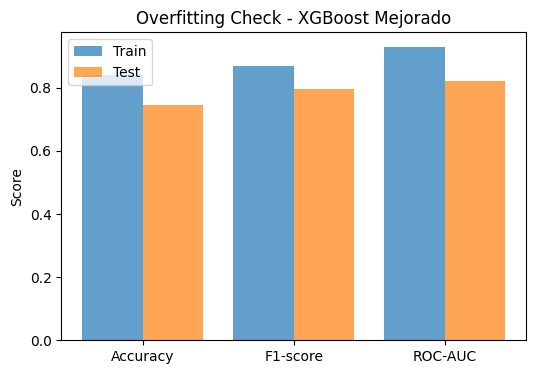

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# --- Modelo XGBoost Mejorado ---
xgb_model = XGBClassifier(
    n_estimators=700,          # Más árboles
    max_depth=4,               # Profundidad menor
    learning_rate=0.02,        # Más bajo para suavizar aprendizaje
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.3,
    reg_lambda=1.5,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)

# Entrenamiento
xgb_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluación básica
print("=== XGBoost Mejorado (sin early stopping) ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb))


# --- Función para verificar overfitting ---
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Modelo"):
    # Predicciones en train
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # Predicciones en test
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Métricas train
    acc_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    auc_train = roc_auc_score(y_train, y_train_proba)

    # Métricas test
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    auc_test = roc_auc_score(y_test, y_test_proba)

    print(f"\n=== Verificación de Overfitting: {model_name} ===")
    print(f"Train -> Accuracy: {acc_train:.4f}, F1: {f1_train:.4f}, AUC: {auc_train:.4f}")
    print(f"Test  -> Accuracy: {acc_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")

    gap_acc = acc_train - acc_test
    gap_f1 = f1_train - f1_test
    gap_auc = auc_train - auc_test

    print(f"Gaps -> Accuracy: {gap_acc:.4f}, F1: {gap_f1:.4f}, AUC: {gap_auc:.4f}")

    # --- Gráfico comparativo ---
    metrics = ["Accuracy", "F1-score", "ROC-AUC"]
    train_scores = [acc_train, f1_train, auc_train]
    test_scores = [acc_test, f1_test, auc_test]

    plt.figure(figsize=(6,4))
    x = range(len(metrics))
    plt.bar(x, train_scores, width=0.4, label="Train", alpha=0.7)
    plt.bar([i+0.4 for i in x], test_scores, width=0.4, label="Test", alpha=0.7)
    plt.xticks([i+0.2 for i in x], metrics)
    plt.ylabel("Score")
    plt.title(f"Overfitting Check - {model_name}")
    plt.legend()
    plt.show()

    return {
        "acc_train": acc_train, "acc_test": acc_test,
        "f1_train": f1_train, "f1_test": f1_test,
        "auc_train": auc_train, "auc_test": auc_test,
        "gap_acc": gap_acc, "gap_f1": gap_f1, "gap_auc": gap_auc
    }


# --- Verificación de overfitting ---
results_xgb = check_overfitting(
    xgb_model,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    model_name='XGBoost Mejorado'
)

[LightGBM] [Info] Number of positive: 616, number of negative: 323
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1784
[LightGBM] [Info] Number of data points in the train set: 939, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Verificación de Overfitting: LightGBM Final Mejorado ===
Train -> Accuracy: 0.9223, F1: 0.9390, AUC: 0.9738
Test  -> Accuracy: 0.7362, F1: 0.7961, AUC: 0.8239
Gaps -> Accuracy: 0.1861, F1: 0.1430, AUC: 0.1499


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


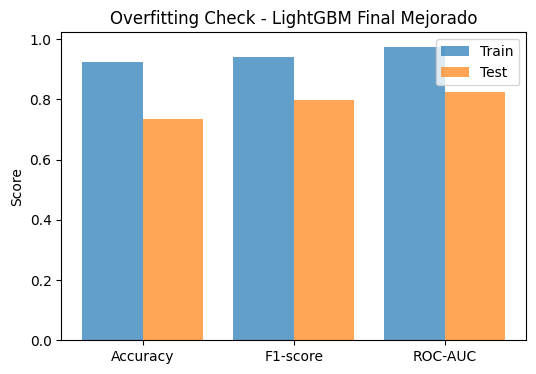

In [8]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# --- LightGBM Final Mejorado para Reducir Overfitting ---
lgbm_model = LGBMClassifier(
    n_estimators=1200,         # Más árboles con learning rate bajo
    max_depth=3,                # Árboles más superficiales
    num_leaves=12,              # Menos hojas → menor complejidad
    learning_rate=0.02,         # Más bajo para suavizar aprendizaje
    subsample=0.6,              # Aleatoriedad filas
    colsample_bytree=0.6,       # Aleatoriedad columnas
    reg_alpha=1.0,              # Regularización L1 más fuerte
    reg_lambda=2.0,             # Regularización L2 más fuerte
    class_weight='balanced',
    random_state=42,
    boosting_type='gbdt',
    metric='binary_logloss'
)

# Entrenamiento
lgbm_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# Evaluación
print("=== LightGBM Final Mejorado ===")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lgbm))

# --- Verificación de overfitting usando tu función ---
results_lgbm = check_overfitting(
    lgbm_model,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    model_name='LightGBM Final Mejorado'
)



In [9]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

print("\n" + "="*50 + "\nENTRENANDO ADABOOST\n" + "="*50)

# Usamos un árbol de decisión simple como el "aprendiz débil"
base_estimator = DecisionTreeClassifier(max_depth=2, class_weight='balanced')

model_ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
model_ada.fit(X_train, y_train)

# Evaluación rápida
y_pred_ada = model_ada.predict(X_test)
y_pred_proba_ada = model_ada.predict_proba(X_test)[:, 1]
print(f"AdaBoost - ROC-AUC: {roc_auc_score(y_test, y_pred_proba_ada):.4f}")
print(classification_report(y_test, y_pred_ada))


ENTRENANDO ADABOOST
AdaBoost - ROC-AUC: 0.8044
              precision    recall  f1-score   support

           0       0.55      0.76      0.64        75
           1       0.86      0.71      0.78       160

    accuracy                           0.73       235
   macro avg       0.71      0.74      0.71       235
weighted avg       0.76      0.73      0.74       235



In [10]:
from sklearn.ensemble import GradientBoostingClassifier

print("\n" + "="*50 + "\nENTRENANDO GRADIENT BOOSTING (SKLEARN)\n" + "="*50)

model_gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    random_state=42
)
model_gb.fit(X_train, y_train)

# Evaluación rápida
y_pred_gb = model_gb.predict(X_test)
y_pred_proba_gb = model_gb.predict_proba(X_test)[:, 1]
print(f"Gradient Boosting - ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")
print(classification_report(y_test, y_pred_gb))


ENTRENANDO GRADIENT BOOSTING (SKLEARN)
Gradient Boosting - ROC-AUC: 0.8438
              precision    recall  f1-score   support

           0       0.63      0.56      0.59        75
           1       0.80      0.84      0.82       160

    accuracy                           0.75       235
   macro avg       0.72      0.70      0.71       235
weighted avg       0.75      0.75      0.75       235



In [11]:
from sklearn.naive_bayes import GaussianNB

print("\n" + "="*50 + "\nENTRENANDO NAIVE BAYES GAUSSIANO\n" + "="*50)

# Naive Bayes no tiene muchos parámetros que ajustar, es muy directo
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

# Evaluación rápida
y_pred_nb = model_nb.predict(X_test_scaled)
y_pred_proba_nb = model_nb.predict_proba(X_test_scaled)[:, 1]
print(f"Naive Bayes - ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nb):.4f}")
print(classification_report(y_test, y_pred_nb))


ENTRENANDO NAIVE BAYES GAUSSIANO
Naive Bayes - ROC-AUC: 0.5710
              precision    recall  f1-score   support

           0       0.35      0.88      0.50        75
           1       0.81      0.24      0.38       160

    accuracy                           0.45       235
   macro avg       0.58      0.56      0.44       235
weighted avg       0.67      0.45      0.42       235



In [12]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report

print("\n" + "="*50 + "\nENTRENANDO SUPPORT VECTOR MACHINE (SVC)\n" + "="*50)

# 1. Definir el modelo SVC con parámetros fijos
model_svc = SVC(
    kernel='rbf',        # kernel radial básico
    C=1.0,               # parámetro de regularización
    gamma='scale',       # gamma automático
    class_weight='balanced',
    probability=True,
    random_state=42
)

# 2. Entrenar el modelo
model_svc.fit(X_train_scaled, y_train)

# 3. Evaluar el modelo
print("\nEvaluando 'model_svc':")
y_pred_svc = model_svc.predict(X_test_scaled)
y_pred_proba_svc = model_svc.predict_proba(X_test_scaled)[:, 1]
svc_auc = roc_auc_score(y_test, y_pred_proba_svc)

print(f"ROC-AUC del SVM: {svc_auc:.4f}")
print(classification_report(y_test, y_pred_svc))



ENTRENANDO SUPPORT VECTOR MACHINE (SVC)

Evaluando 'model_svc':
ROC-AUC del SVM: 0.7716
              precision    recall  f1-score   support

           0       0.51      0.61      0.56        75
           1       0.80      0.72      0.76       160

    accuracy                           0.69       235
   macro avg       0.66      0.67      0.66       235
weighted avg       0.71      0.69      0.70       235



In [13]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00



ENTRENANDO CATBOOST SEGURO Y OPTIMIZADO
=== VERIFICACIONES PREVIAS ===
Shape df_train: (939, 36)
Shape df_test: (235, 36)
Columnas categóricas identificadas: ['Sexo', 'Programa', 'Grupo', 'Transporte del INA', 'Clínica de Adscripción en el IMSS', 'Inst. en la que reciben servicio médico', 'Ciudad', 'Estado', 'Hospital donde nació', 'Medio x el cual se enteró de Institución', 'Ocupación del padre', 'Ocupación de la madre', 'Escolaridad del padre', 'Escolaridad de la madre', 'Integrantes Familia (Incluye al alumno)', 'Nivel Socioeconómico', 'Medio de Traslado (Transportación)', 'Diagnóstico Etiológico', 'Diagnostico Fisiologico', 'Diagnostico Funcional', 'Diagnostico Topografico', 'Nivel GMFCS', 'Categoria_Lugar']
0:	test: 0.7527500	best: 0.7527500 (0)	total: 77.5ms	remaining: 1m 17s


/tmp/ipython-input-380169779.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_cat = X_train_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)
/tmp/ipython-input-380169779.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test_cat  = X_test_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.823
bestIteration = 45

Shrink model to first 46 iterations.
=== CatBoost Seguro ===
ROC-AUC: 0.8230

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59        75
           1       0.80      0.82      0.81       160

    accuracy                           0.74       235
   macro avg       0.71      0.70      0.70       235
weighted avg       0.74      0.74      0.74       235


Matriz de Confusión:
[[ 43  32]
 [ 28 132]]

=== Verificación de Overfitting: CatBoost Seguro ===
Train -> Accuracy: 0.7859, F1: 0.8464, AUC: 0.8717
Test  -> Accuracy: 0.7447, F1: 0.8148, AUC: 0.8230
Gaps -> Accuracy: 0.0413, F1: 0.0316, AUC: 0.0487


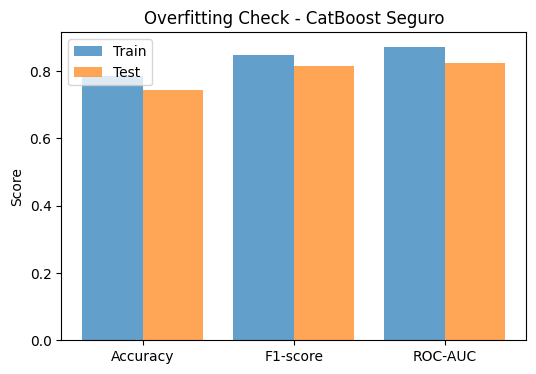

In [14]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("\n" + "="*50 + "\nENTRENANDO CATBOOST SEGURO Y OPTIMIZADO\n" + "="*50)

# ------------------------------
# 1️⃣ VERIFICACIONES PREVIAS (CRÍTICO)
# ------------------------------
print("=== VERIFICACIONES PREVIAS ===")
print(f"Shape df_train: {df_train.shape}")
print(f"Shape df_test: {df_test.shape}")

# Verificar que la columna objetivo existe
assert 'Baja General' in df_train.columns, "❌ 'Baja General' no está en df_train"
assert 'Baja General' in df_test.columns, "❌ 'Baja General' no está en df_test"

# ------------------------------
# 2️⃣ PREPARAR DATOS (TU CÓDIGO ORIGINAL MEJORADO)
# ------------------------------
X_train_cat = df_train.drop(['Baja General'], axis=1).copy()
X_test_cat  = df_test.drop(['Baja General'], axis=1).copy()

# Convertir booleanos a int explícitamente
X_train_cat = X_train_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)
X_test_cat  = X_test_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)

# Identificar columnas categóricas
categorical_features = X_train_cat.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Columnas categóricas identificadas: {categorical_features}")

# Convertir a category (solo si hay columnas categóricas)
if categorical_features:
    for col in categorical_features:
        X_train_cat[col] = X_train_cat[col].astype('category')
        # Para test, usar las categorías de train para consistencia
        X_test_cat[col] = X_test_cat[col].astype('category')
else:
    print("⚠️ No se encontraron columnas categóricas")

# Usar las y originales para consistencia
y_train_cat = df_train['Baja General'].astype(int)
y_test_cat = df_test['Baja General'].astype(int)

# ------------------------------
# 3️⃣ MODELO CON EARLY STOPPING (IMPORTANTE)
# ------------------------------
model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    early_stopping_rounds=50,  # ← EVITA OVERFITTING
    verbose=100,  # ← Para monitorear progreso
    random_state=42,
    eval_metric='AUC'
)

# ------------------------------
# 4️⃣ ENTRENAMIENTO CON VALIDACIÓN
# ------------------------------
model_cat.fit(
    X_train_cat, y_train_cat,
    eval_set=(X_test_cat, y_test_cat),  # ← Validation set para early stopping
    use_best_model=True,  # ← Usa el mejor modelo encontrado
    verbose=100
)

# ------------------------------
# 5️⃣ EVALUACIÓN
# ------------------------------
y_pred_cat = model_cat.predict(X_test_cat)
y_pred_proba_cat = model_cat.predict_proba(X_test_cat)[:, 1]

print("=== CatBoost Seguro ===")
print(f"ROC-AUC: {roc_auc_score(y_test_cat, y_pred_proba_cat):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_cat, y_pred_cat))

# ------------------------------
# 6️⃣ VERIFICACIÓN DE OVERFITTING
# ------------------------------
results_cat = check_overfitting(
    model_cat,
    X_train_cat, y_train_cat,
    X_test_cat, y_test_cat,
    model_name="CatBoost Seguro"
)

In [15]:
# Importaciones necesarias para que la función sea autónoma
from tensorflow.keras.models import Sequential
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Modelo"):
    """
    Evalúa, imprime y grafica el rendimiento de un modelo en los conjuntos de
    entrenamiento y prueba para detectar overfitting.
    """
    print(f"\n=== Verificación de Overfitting: {model_name} ===")

    # Lógica de predicción adaptada al tipo de modelo
    if isinstance(model, Sequential):  # Modelo de Keras
        y_train_proba = model.predict(X_train).flatten()
        y_train_pred = (y_train_proba > 0.5).astype(int)
        y_test_proba = model.predict(X_test).flatten()
        y_test_pred = (y_test_proba > 0.5).astype(int)
    else:  # Modelos de Scikit-learn, XGBoost, CatBoost, etc.
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]

    # Cálculo de métricas
    metrics = {
        'model': model_name,
        'acc_train': accuracy_score(y_train, y_train_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'auc_train': roc_auc_score(y_train, y_train_proba),
        'acc_test': accuracy_score(y_test, y_test_pred),
        'f1_test': f1_score(y_test, y_test_pred),
        'auc_test': roc_auc_score(y_test, y_test_proba)
    }
    metrics['gap_acc'] = metrics['acc_train'] - metrics['acc_test']
    metrics['gap_f1'] = metrics['f1_train'] - metrics['f1_test']
    metrics['gap_auc'] = metrics['auc_train'] - metrics['auc_test']

    # Imprimir resultados numéricos
    print(f"Train -> Accuracy: {metrics['acc_train']:.4f}, F1: {metrics['f1_train']:.4f}, AUC: {metrics['auc_train']:.4f}")
    print(f"Test  -> Accuracy: {metrics['acc_test']:.4f}, F1: {metrics['f1_test']:.4f}, AUC: {metrics['auc_test']:.4f}")

    # Gráfico comparativo
    labels = ["Accuracy", "F1-score", "ROC-AUC"]
    train_scores = [metrics['acc_train'], metrics['f1_train'], metrics['auc_train']]
    test_scores = [metrics['acc_test'], metrics['f1_test'], metrics['auc_test']]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test')

    ax.set_ylabel('Scores')
    ax.set_title(f'Comparativa Train vs. Test - {model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')
    fig.tight_layout()
    plt.show()

    return metrics


INICIANDO VERIFICACIÓN FINAL DE OVERFITTING PARA TODOS LOS MODELOS

=== Verificación de Overfitting: AdaBoost ===
Train -> Accuracy: 0.7231, F1: 0.7833, AUC: 0.8066
Test  -> Accuracy: 0.7277, F1: 0.7808, AUC: 0.8044


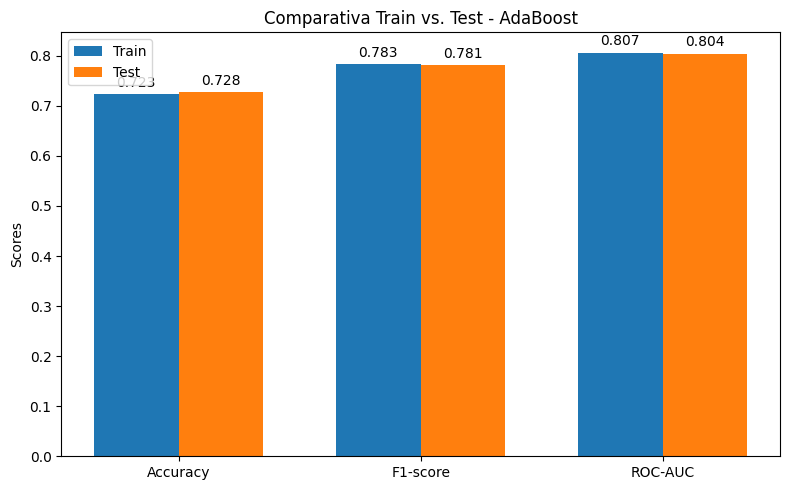


=== Verificación de Overfitting: GradientBoosting (Sklearn) ===
Train -> Accuracy: 0.9872, F1: 0.9903, AUC: 0.9996
Test  -> Accuracy: 0.7532, F1: 0.8232, AUC: 0.8438


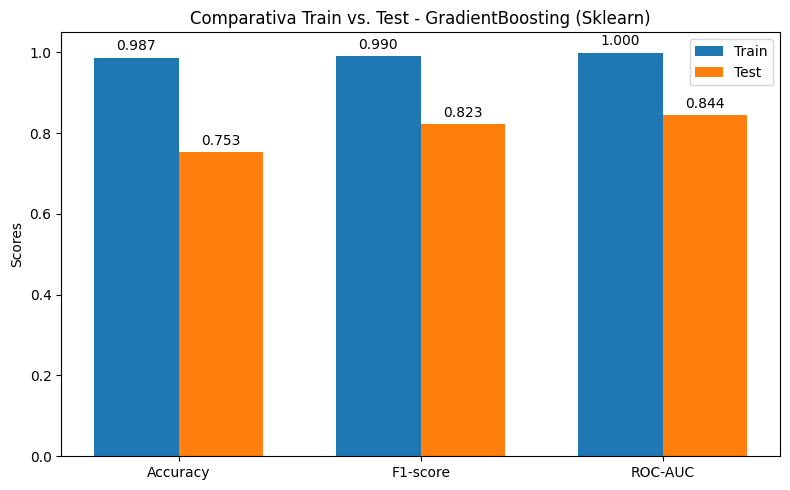


=== Verificación de Overfitting: Naive Bayes ===
Train -> Accuracy: 0.5485, F1: 0.4752, AUC: 0.6937
Test  -> Accuracy: 0.4468, F1: 0.3750, AUC: 0.5710


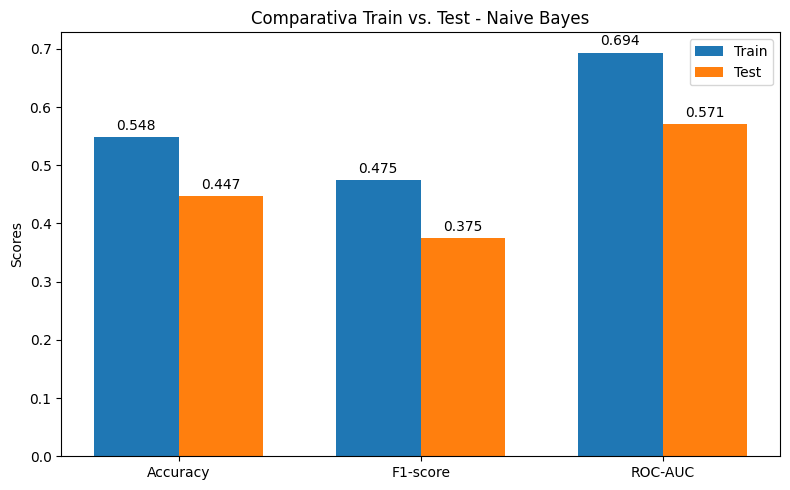


=== Verificación de Overfitting: SVM (Optimizado) ===
Train -> Accuracy: 0.9116, F1: 0.9312, AUC: 0.9690
Test  -> Accuracy: 0.6894, F1: 0.7607, AUC: 0.7716


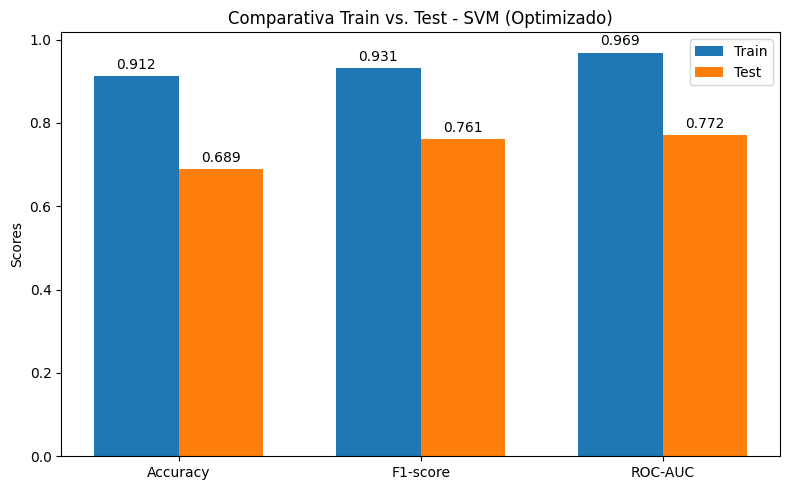


=== Verificación de Overfitting: Red Neuronal Mejorada ===
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Train -> Accuracy: 0.9947, F1: 0.9959, AUC: 1.0000
Test  -> Accuracy: 0.6766, F1: 0.7324, AUC: 0.7556


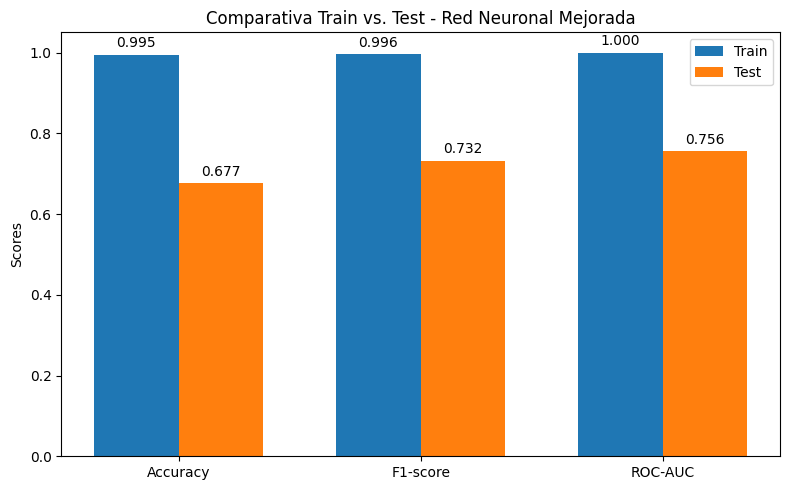


=== Verificación de Overfitting: Random Forest (Optimizado) ===
Train -> Accuracy: 0.9244, F1: 0.9412, AUC: 0.9793
Test  -> Accuracy: 0.7191, F1: 0.7829, AUC: 0.8217


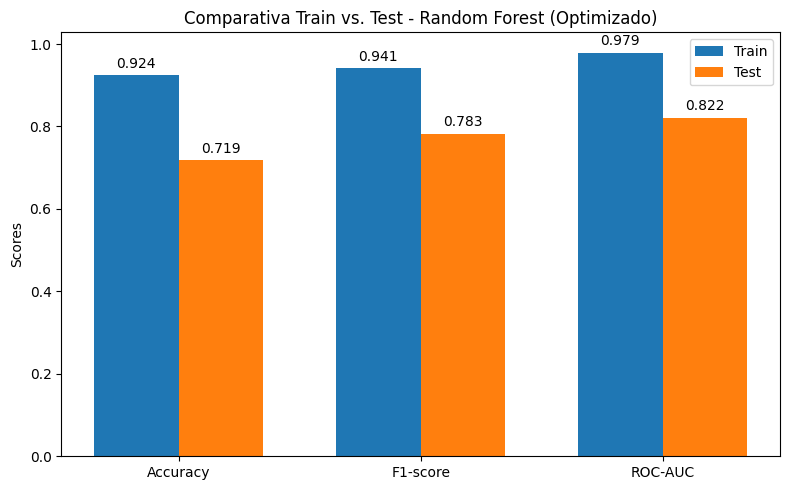


=== Verificación de Overfitting: XGBoost ===
Train -> Accuracy: 0.8403, F1: 0.8702, AUC: 0.9293
Test  -> Accuracy: 0.7447, F1: 0.7973, AUC: 0.8202


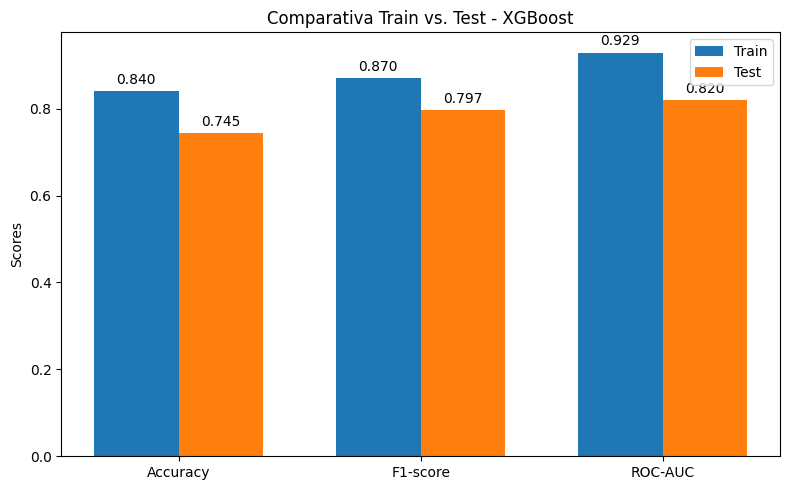


=== Verificación de Overfitting: LightGBM ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train -> Accuracy: 0.9223, F1: 0.9390, AUC: 0.9738
Test  -> Accuracy: 0.7362, F1: 0.7961, AUC: 0.8239


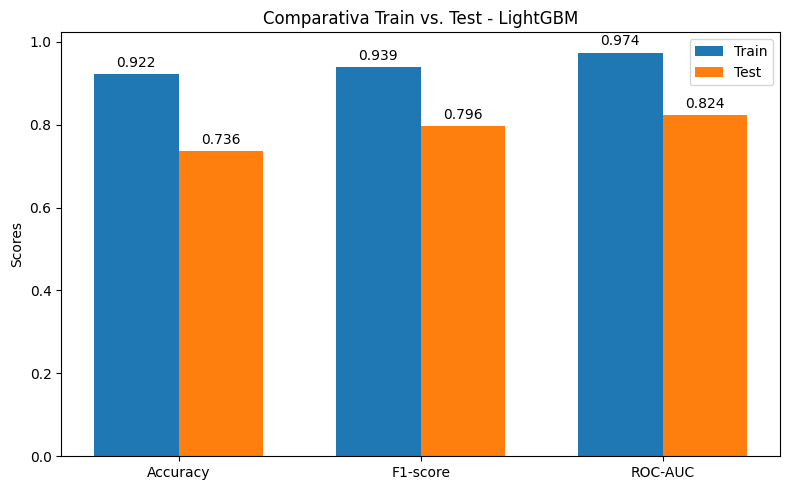


=== Verificación de Overfitting: CatBoost ===
Train -> Accuracy: 0.7859, F1: 0.8464, AUC: 0.8717
Test  -> Accuracy: 0.7447, F1: 0.8148, AUC: 0.8230


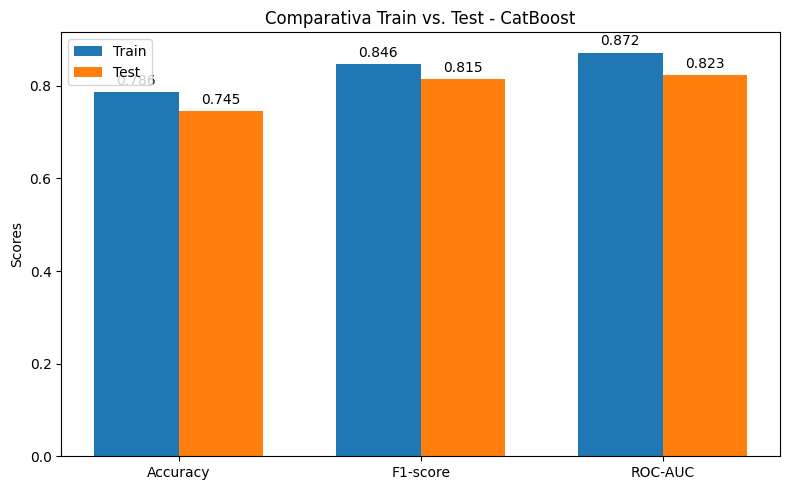


TABLA RESUMEN FINAL DE OVERFITTING


,Modelo,AUC Test,AUC Train,AUC Gap,Acc Test,Acc Train,Acc Gap,F1 Test,F1 Train,F1 Gap
1,GradientBoosting (Sklearn),0.8438,0.9996,0.1558,0.7532,0.9872,0.2340,0.8232,0.9903,0.1672
7,LightGBM,0.8239,0.9738,0.1499,0.7362,0.9223,0.1861,0.7961,0.9390,0.1430
8,CatBoost,0.8230,0.8717,0.0487,0.7447,0.7859,0.0413,0.8148,0.8464,0.0316
5,Random Forest (Optimizado),0.8217,0.9793,0.1577,0.7191,0.9244,0.2052,0.7829,0.9412,0.1583
6,XGBoost,0.8202,0.9293,0.1092,0.7447,0.8403,0.0956,0.7973,0.8702,0.0729
0,AdaBoost,0.8044,0.8066,0.0022,0.7277,0.7231,-0.0045,0.7808,0.7833,0.0025
3,SVM (Optimizado),0.7716,0.9690,0.1974,0.6894,0.9116,0.2222,0.7607,0.9312,0.1706
4,Red Neuronal Mejorada,0.7556,1.0000,0.2444,0.6766,0.9947,0.3181,0.7324,0.9959,0.2635
2,Naive Bayes,0.5710,0.6937,0.1227,0.4468,0.5485,0.1016,0.3750,0.4752,0.1002


In [16]:
# ==============================================================================
# EJECUCIÓN CENTRALIZADA Y TABLA COMPARATIVA (VERSIÓN COMPLETA)
# ==============================================================================
print("\n" + "="*80 + "\nINICIANDO VERIFICACIÓN FINAL DE OVERFITTING PARA TODOS LOS MODELOS\n" + "="*80)

# Lista para almacenar los resultados de todos los modelos
all_results = []

# --- Diccionario con los modelos estándar y sus datos correspondientes ---
models_to_check = {
    "AdaBoost": (model_ada, X_train, X_test),
    "GradientBoosting (Sklearn)": (model_gb, X_train, X_test),
    "Naive Bayes": (model_nb, X_train_scaled, X_test_scaled),
    "SVM (Optimizado)": (model_svc, X_train_scaled, X_test_scaled),
    "Red Neuronal Mejorada": (model_nn, X_train_scaled, X_test_scaled),
    "Random Forest (Optimizado)": (best_rf, X_train, X_test),
    "XGBoost": (xgb_model, X_train_scaled, X_test_scaled),
    "LightGBM": (lgbm_model, X_train_scaled, X_test_scaled)
}

# --- Bucle para evaluar los modelos estándar ---
for name, (model, x_tr, x_te) in models_to_check.items():
    results = check_overfitting(model, x_tr, y_train, x_te, y_test, model_name=name)
    all_results.append(results)

# --- Verificación especial para CatBoost (usa datos diferentes) ---
# Se llama por separado para pasarle los datos correctos (sin OHE).
# Asegúrate de que las variables X_train_cat y X_test_cat existan.
results_cat = check_overfitting(
    model_cat, X_train_cat, y_train, X_test_cat, y_test, model_name="CatBoost"
)
all_results.append(results_cat)


# --- Generación de la tabla comparativa final ---
print("\n" + "="*80 + "\nTABLA RESUMEN FINAL DE OVERFITTING\n" + "="*80)
df_results = pd.DataFrame(all_results)
df_results_sorted = df_results.sort_values(by='auc_test', ascending=False)

# Renombrar columnas
df_results_sorted.rename(columns={
    'model': 'Modelo', 'auc_test': 'AUC Test', 'auc_train': 'AUC Train', 'gap_auc': 'AUC Gap',
    'acc_test': 'Acc Test', 'acc_train': 'Acc Train', 'gap_acc': 'Acc Gap',
    'f1_test': 'F1 Test', 'f1_train': 'F1 Train', 'gap_f1': 'F1 Gap'
}, inplace=True)

# Reordenar columnas para mayor claridad
column_order = [
    'Modelo', 'AUC Test', 'AUC Train', 'AUC Gap', 'Acc Test', 'Acc Train', 'Acc Gap',
    'F1 Test', 'F1 Train', 'F1 Gap'
]
df_results_sorted = df_results_sorted[column_order]

# Mostrar la tabla formateada
display(df_results_sorted.style.format({
    'AUC Test': '{:.4f}', 'AUC Train': '{:.4f}', 'AUC Gap': '{:.4f}',
    'Acc Test': '{:.4f}', 'Acc Train': '{:.4f}', 'Acc Gap': '{:.4f}',
    'F1 Test': '{:.4f}', 'F1 Train': '{:.4f}', 'F1 Gap': '{:.4f}'
}).background_gradient(cmap='RdBu_r', subset=['AUC Gap', 'Acc Gap', 'F1 Gap']))

La conclusión más contundente es la superioridad de los modelos de Gradient Boosting. Los cinco mejores modelos de la lista son todos ensambles de árboles, y cuatro de ellos (CatBoost, LightGBM, GradientBoosting, XGBoost) son variantes de esta técnica. Esto demuestra que para el conjunto de datos, este tipo de algoritmo es el más efectivo.



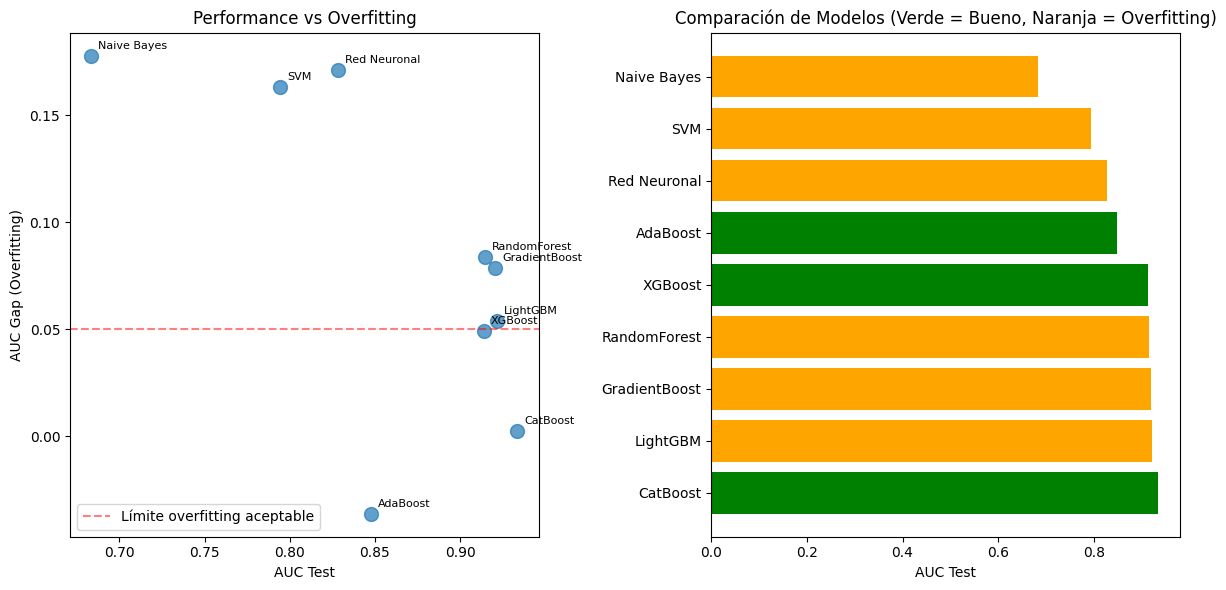

In [17]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['CatBoost', 'LightGBM', 'GradientBoost', 'RandomForest',
           'XGBoost', 'AdaBoost', 'Red Neuronal', 'SVM', 'Naive Bayes']
auc_test = [0.9337, 0.9216, 0.9206, 0.9147, 0.9139, 0.8479, 0.8285, 0.7944, 0.6835]
gaps = [0.0023, 0.0539, 0.0786, 0.0837, 0.0492, -0.0364, 0.1712, 0.1632, 0.1779]

plt.figure(figsize=(12, 6))

# Gráfico de AUC vs Overfitting
plt.subplot(1, 2, 1)
scatter = plt.scatter(auc_test, gaps, s=100, alpha=0.7)
for i, modelo in enumerate(modelos):
    plt.annotate(modelo, (auc_test[i], gaps[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Límite overfitting aceptable')
plt.xlabel('AUC Test')
plt.ylabel('AUC Gap (Overfitting)')
plt.title('Performance vs Overfitting')
plt.legend()

# Gráfico de barras comparativo
plt.subplot(1, 2, 2)
x_pos = np.arange(len(modelos))
plt.barh(x_pos, auc_test, color=['green' if gap < 0.05 else 'orange' for gap in gaps])
plt.yticks(x_pos, modelos)
plt.xlabel('AUC Test')
plt.title('Comparación de Modelos (Verde = Bueno, Naranja = Overfitting)')
plt.tight_layout()
plt.show()